# 01. Pierwsze drzewo decyzyjne: kupić lody?

Cel: zbudować pierwsze drzewo **ręcznie**, a dopiero potem porównać je z `DecisionTreeClassifier`.

Przykład jest celowo mały. Każdy wiersz to jedna sytuacja, a celem jest decyzja `kup_lody`.

Legenda cech:

| cecha | 1 oznacza | 0 oznacza |
|---|---|---|
| `cieplo` | jest ciepło | nie jest ciepło |
| `weekend` | jest weekend | dzień powszedni |
| `krotka_kolejka` | kolejka jest krótka | kolejka jest długa |

Po zajęciach student powinien umieć odpowiedzieć:

1. Co oznacza „nieczystość” w węźle drzewa?
2. Jak wybrać pierwszy podział?
3. Jak zamienić drzewo na proste reguły `if/else`?

# 1. Co to są za dane?

Mamy bardzo prosty, sztuczny przykład: **czy kupimy lody?**

Każdy wiersz to jedna sytuacja, np. jeden dzień albo jedna decyzja.

Kolumny:

- `cieplo`  
  - `1` oznacza: jest ciepło  
  - `0` oznacza: nie jest ciepło

- `weekend`  
  - `1` oznacza: jest weekend  
  - `0` oznacza: nie jest weekend

- `krotka_kolejka`  
  - `1` oznacza: kolejka jest krótka  
  - `0` oznacza: kolejka nie jest krótka

- `kup_lody`  
  - `tak` oznacza: kupujemy lody  
  - `nie` oznacza: nie kupujemy lodów

Przykładowy wiersz:

| cieplo | weekend | krotka_kolejka | kup_lody |
|---:|---:|---:|---|
| 1 | 1 | 0 | tak |

czytamy jako:

> Jest ciepło, jest weekend, kolejka nie jest krótka, ale mimo to kupujemy lody.

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Szukamy pliku CSV w katalogu projektu.
# Dzięki temu notebook działa zarówno z katalogu głównego projektu,
# jak i z podkatalogu, np. notebooks/.
BASE = Path.cwd()
if not (BASE / "data").exists():
    BASE = BASE.parent

csv_path = BASE / "data" / "01_lody.csv"

if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    # Fallback dydaktyczny: gdy notebook jest uruchamiany bez katalogu data/,
    # tworzymy mały zbiór danych bezpośrednio w notebooku.
    df = pd.DataFrame({
        "id": list(range(1, 15)),
        "cieplo": [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
        "weekend": [0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0],
        "krotka_kolejka": [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1],
        "kup_lody": ["nie", "nie", "nie", "nie", "nie", "tak", "tak", "tak",
                      "tak", "nie", "tak", "nie", "tak", "tak"]
    })

df

,id,cieplo,weekend,krotka_kolejka,kup_lody
0,1,0,0,0,nie
1,2,0,0,1,nie
2,3,0,1,0,nie
3,4,0,1,1,nie
4,5,1,0,0,nie
5,6,1,0,1,tak
6,7,1,1,0,tak
7,8,1,1,1,tak
8,9,1,0,1,tak
9,10,0,1,1,nie


## 1. Drzewo jako seria pytań

Drzewo decyzyjne nie zaczyna od „magii”. Ono zadaje proste pytania, na przykład:

```text
Czy jest ciepło?
├── nie  -> nie kupujemy lodów
└── tak  -> zadaj kolejne pytanie
```

Najważniejsze pytanie dydaktyczne brzmi: **które pytanie zadać jako pierwsze?**

Jedna intuicja: dobre pytanie rozdziela dane tak, żeby w każdym dziecku było możliwie dużo przykładów jednej klasy.

In [7]:
# Ile mamy decyzji „tak” i „nie” w całym zbiorze?
df["kup_lody"].value_counts()

nie    7
tak    7
Name: kup_lody, dtype: int64

## 2. Nieczystość Giniego

Dla klasyfikacji często używa się miary Giniego:

$$Gini = 1 - \sum_k p_k^2$$

Jeżeli w węźle są same przykłady jednej klasy, Gini = 0. Jeżeli klasy są wymieszane pół na pół, Gini jest większe.

## Gini impurity i zysk Giniego

W drzewach decyzyjnych chcemy tworzyć podziały danych (splity), które jak najlepiej rozdzielają klasy.

Do mierzenia „chaosu” klas używa się m.in. **Gini impurity**.

Dla problemu binarnego:

$$
G = 1 - p_0^2 - p_1^2
$$

gdzie:
- $p_0$ — prawdopodobieństwo klasy 0,
- $p_1$ — prawdopodobieństwo klasy 1.

Można też zapisać:

$$
G = 2p(1-p)
$$

gdzie:
- $p$ oznacza prawdopodobieństwo jednej z klas.

---

### Interpretacja

- $G=0$ → dane są idealnie czyste (same 0 lub same 1),
- $G=0.5$ → maksymalny chaos dla dwóch klas (50% / 50%).

Im bardziej klasy są wymieszane, tym większa wartość Gini impurity.

---

### Zysk Giniego (Gini gain)

Drzewo decyzyjne sprawdza, jak bardzo split zmniejsza chaos klas.

Najpierw liczymy impurity przed podziałem:

$$
G_{\text{before}}
$$

Następnie impurity po podziale:

$$
G_{\text{after}}
=
\frac{N_L}{N}G_L
+
\frac{N_R}{N}G_R
$$

gdzie:
- $N_L$, $N_R$ — liczba elementów po lewej i prawej stronie splitu,
- $G_L$, $G_R$ — impurity dla obu grup.

Zysk Giniego:

$$
\text{Gini Gain}
=
G_{\text{before}}
-
G_{\text{after}}
$$

Im większy zysk Giniego:
- tym lepszy split,
- tym lepiej dane zostały uporządkowane przez drzewo.

---

### Intuicja

Drzewo decyzyjne szuka pytań typu:

> „Czy ta cecha pozwala lepiej oddzielić klasy?”

Dobry split:
- zmniejsza chaos,
- zwiększa czystość grup,
- prowadzi do bardziej jednoznacznych decyzji klasyfikacyjnych.

### Skąd się bierze wzór \(G = 2p(1-p)\)?

Dla dwóch klas zaczynamy od definicji:

$$
G = 1 - p_0^2 - p_1^2
$$

Jeżeli oznaczymy prawdopodobieństwo jednej klasy jako \(p\), to druga klasa ma prawdopodobieństwo \(1-p\):

$$
p_1 = p
$$

$$
p_0 = 1-p
$$

Podstawiamy:

$$
G = 1 - (1-p)^2 - p^2
$$

Rozwijamy kwadrat:

$$
(1-p)^2 = 1 - 2p + p^2
$$

czyli:

$$
G = 1 - (1 - 2p + p^2) - p^2
$$

$$
G = 1 - 1 + 2p - p^2 - p^2
$$

$$
G = 2p - 2p^2
$$

Wyciągamy \(2p\) przed nawias:

$$
G = 2p(1-p)
$$

Dla problemu binarnego maksimum tej funkcji pojawia się przy \(p = 0.5\),
czyli wtedy, gdy klasy są wymieszane pół na pół.

---

### Co oznaczają `before`, `after`, `left` i `right`?

Drzewo w każdym węźle zadaje pytanie:

> Czy warto rozdzielić ten węzeł na dwa mniejsze węzły?

**Before** oznacza stan przed podziałem.  
Mamy jeden aktualny węzeł i liczymy jego nieczystość:

$$
G_{\text{before}}
$$

**Left** i **right** to dwie grupy po podziale.  
Dla każdej z nich liczymy osobne impurity:

$$
G_L
$$

oraz:

$$
G_R
$$

**After** to łączny wynik podziału, liczony jako średnia ważona impurity obu dzieci:

$$
G_{\text{after}}
=
\frac{N_L}{N}G_L
+
\frac{N_R}{N}G_R
$$

Zysk Giniego to różnica:

$$
\text{Gain}
=
G_{\text{before}}
-
G_{\text{after}}
$$

Jeżeli split jest dobry, to:

$$
G_{\text{after}} < G_{\text{before}}
$$

czyli po podziale klasy są mniej wymieszane niż przed podziałem.


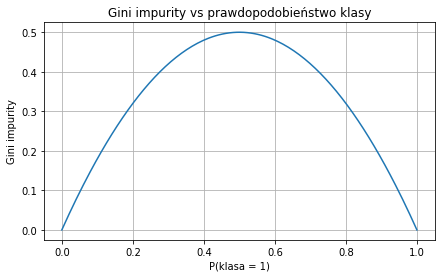

In [4]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0, 1, 200)

gini = 1 - p**2 - (1-p)**2
#gini = 1 - p**2 - (1-p)**2

plt.figure(figsize=(7,4))
plt.plot(p, gini)

plt.xlabel('P(klasa = 1)')
plt.ylabel('Gini impurity')
plt.title('Gini impurity vs prawdopodobieństwo klasy')

plt.grid(True)
plt.show()

In [8]:
def gini(labels):
    """Nieczystość Giniego dla serii etykiet."""
    probs = labels.value_counts(normalize=True)
    return 1 - np.sum(probs ** 2)

parent_gini = gini(df["kup_lody"])
parent_gini

0.5

## 3. Jak ocenić pojedynczy podział?

Dla każdej cechy sprawdzamy podział na dwie grupy: `cecha == 0` i `cecha == 1`.

Wynik podziału to średnia ważona nieczystości dzieci. Im niżej, tym lepiej.

In [9]:
def split_score(data, feature, target="kup_lody"):
    rows = []
    weighted_gini = 0
    n_total = len(data)

    for value, part in data.groupby(feature):
        part_gini = gini(part[target])
        weight = len(part) / n_total
        weighted_gini += weight * part_gini
        rows.append({
            "cecha": feature,
            "wartosc": value,
            "liczba_wierszy": len(part),
            "klasy": dict(part[target].value_counts()),
            "gini_dziecka": round(part_gini, 3),
            "waga": round(weight, 3)
        })

    return weighted_gini, pd.DataFrame(rows)

scores = []
for feature in ["cieplo", "weekend", "krotka_kolejka"]:
    score, details = split_score(df, feature)
    scores.append({"cecha": feature, "gini_po_podziale": score, "zysk_gini": parent_gini - score})

pd.DataFrame(scores).sort_values("gini_po_podziale")

,cecha,gini_po_podziale,zysk_gini
0,cieplo,0.222222,0.277778
2,krotka_kolejka,0.458333,0.041667
1,weekend,0.489796,0.010204


Powyższa tabela mówi, które pierwsze pytanie jest najlepsze. Zysk Giniego to uproszczona wersja myślenia: **ile bałaganu usunęliśmy tym pytaniem?**

In [6]:
# Zobaczmy szczegóły najlepszego pierwszego pytania.
score, details = split_score(df, "cieplo")
details

,cecha,wartosc,liczba_wierszy,klasy,gini_dziecka,waga
0,cieplo,0,5,{'nie': 5},0.000,0.357
1,cieplo,1,9,"{'tak': 7, 'nie': 2}",0.346,0.643


## 4. Ręcznie budujemy drugi poziom

Po pierwszym pytaniu interesuje nas gałąź, która nadal jest mieszana.

W naszym przykładzie gałąź `cieplo == 0` jest prosta: wszystkie obserwacje prowadzą do decyzji `nie`. Gałąź `cieplo == 1` nadal jest mieszana, więc wymaga kolejnego pytania.

In [7]:
warm = df[df["cieplo"] == 1]
print("Gini w gałęzi cieplo == 1:", round(gini(warm["kup_lody"]), 3))

scores_warm = []
for feature in ["weekend", "krotka_kolejka"]:
    score, _ = split_score(warm, feature)
    scores_warm.append({"cecha": feature, "gini_po_podziale": score, "zysk_gini": gini(warm["kup_lody"]) - score})

pd.DataFrame(scores_warm).sort_values("gini_po_podziale")

Gini w gałęzi cieplo == 1: 0.346


,cecha,gini_po_podziale,zysk_gini
1,krotka_kolejka,0.222222,0.123457
0,weekend,0.266667,0.079012


## 5. To samo robi scikit-learn

Teraz uczymy małe drzewo, ale po wcześniejszym ręcznym liczeniu jego wynik nie powinien być zaskoczeniem.

### Co stanie się w `tree.fit(X, y)`?

W tym miejscu model sam szuka dobrych pytań do drzewa.

Dla naszych binarnych cech (`0` albo `1`) możliwy split wygląda np. tak:

```text
cieplo <= 0.5
```

Ponieważ cecha ma tylko wartości `0` i `1`, próg `0.5` oznacza po prostu:

```text
lewa gałąź  -> cieplo = 0
prawa gałąź -> cieplo = 1
```

Model sprawdza takie pytania dla różnych cech, liczy spadek Gini impurity
i wybiera pytanie z największym zyskiem Giniego.


In [10]:
X = df[["cieplo", "weekend", "krotka_kolejka"]]
y = df["kup_lody"]

tree = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree.fit(X, y)

print(export_text(tree, feature_names=list(X.columns)))

|--- cieplo <= 0.50
|   |--- class: nie
|--- cieplo >  0.50
|   |--- krotka_kolejka <= 0.50
|   |   |--- weekend <= 0.50
|   |   |   |--- class: nie
|   |   |--- weekend >  0.50
|   |   |   |--- class: tak
|   |--- krotka_kolejka >  0.50
|   |   |--- class: tak



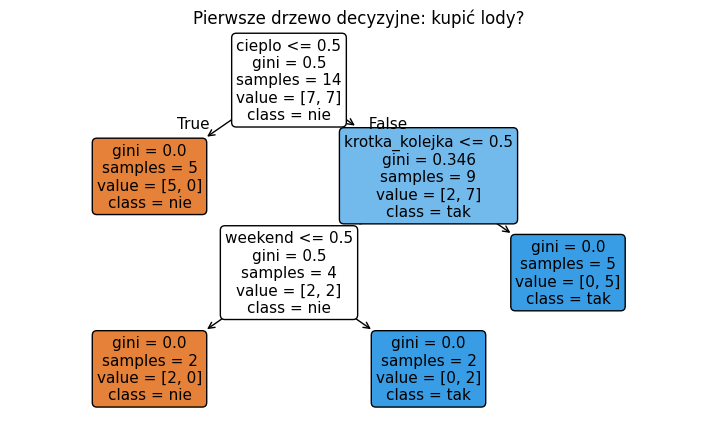

In [9]:
plt.figure(figsize=(9, 5))
plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names=list(tree.classes_),
    filled=True,
    rounded=True,
    impurity=True
)
plt.title("Pierwsze drzewo decyzyjne: kupić lody?")
plt.show()

### Jak czytać narysowane drzewo?

W każdym węźle widzimy kilka informacji:

```text
cecha <= próg
gini = ...
samples = ...
value = [...]
class = ...
```

Znaczenie:

- `cecha <= próg` — pytanie, które zadaje drzewo w tym węźle,
- `gini` — nieczystość Giniego w tym węźle,
- `samples` — liczba obserwacji, które trafiły do tego węzła,
- `value` — liczba obserwacji w każdej klasie,
- `class` — klasa dominująca, czyli predykcja modelu w tym węźle.

Dla cech zero-jedynkowych próg `0.5` jest naturalną granicą między `0` i `1`.

Kolory nie oznaczają gałęzi `True`/`False`.  
Kolory pokazują klasę dominującą w węźle. Im ciemniejszy kolor, tym bardziej „czysty” węzeł.


## 6. Zamiana drzewa na reguły

Przykładowo:

```text
jeżeli cieplo <= 0.5:
    kup_lody = nie
inaczej:
    jeżeli krotka_kolejka <= 0.5:
        sprawdź weekend
    inaczej:
        kup_lody = tak
```

To właśnie dlatego drzewa są wygodne na początku nauki ML: model można czytać jak krótką listę reguł.

In [10]:
# Mini-test: trzy nowe sytuacje
nowe = pd.DataFrame({
    "cieplo": [0, 1, 1],
    "weekend": [1, 0, 1],
    "krotka_kolejka": [1, 0, 0]
})
nowe["predykcja"] = tree.predict(nowe)
nowe

,cieplo,weekend,krotka_kolejka,predykcja
0,0,1,1,nie
1,1,0,0,nie
2,1,1,0,tak


### Jak działa predykcja dla nowych danych?

Gdy wywołujemy:

```python
tree.predict(nowe)
```

każda nowa obserwacja przechodzi przez drzewo od korzenia do liścia.

Model nie liczy już wtedy Gini od nowa.  
Gini było potrzebne podczas uczenia, żeby zbudować drzewo.

Podczas predykcji model tylko wykonuje wyuczone reguły `if/else`, np.:

```text
czy cieplo <= 0.5?
czy krotka_kolejka <= 0.5?
czy weekend <= 0.5?
```

Ostateczna predykcja to klasa dominująca w liściu, do którego trafiła obserwacja.


## Ćwiczenia dla studentów

1. Dopisz jeden wiersz: `cieplo=0`, `weekend=1`, `krotka_kolejka=1`, `kup_lody=tak`. Co stanie się z pierwszym podziałem?
2. Zmień `criterion="entropy"`. Czy drzewo ma taki sam kształt?
3. Ustaw `max_depth=1`. Jak nazywa się tak małe drzewo? Jaki błąd popełnia?
4. Własnymi słowami opisz różnicę między „dobrym pytaniem” a „złym pytaniem” w drzewie.

---

# Dodatki

Główna część notebooka kończy się na ćwiczeniach.  
Poniższe dodatki można potraktować jako materiał uzupełniający:

- Dodatek 1 wyjaśnia dokładniej maksimum funkcji Gini,
- Dodatek 2 pokazuje ręczne liczenie na drugim przykładzie,
- Dodatek 3 pokazuje programistyczne porównanie splitów i wizualizację Graphviz.


# Dodatek 1: dlaczego maksimum Gini jest przy 50/50?


## Dlaczego `2p(1-p)` ma maksimum dla `p = 0.5`?

Mamy:

$$
G = 2p(1-p)
$$

czyli:

$$
G = 2p - 2p^2
$$

To jest parabola skierowana w dół, bo przy $p^2$ stoi minus:

$$
-2p^2
$$

Ale najprościej zobaczyć to przez przekształcenie do postaci z kwadratem:

$$
G = 2p(1-p)
$$

$$
G = 2p - 2p^2
$$

Wyciągamy minus:

$$
G = -2p^2 + 2p
$$

Teraz zapisujemy to jako:

$$
G = -2(p - 0.5)^2 + 0.5
$$

To jest najważniejsza postać.

Ponieważ:

$$
(p - 0.5)^2 \geq 0
$$

czyli kwadrat nigdy nie jest ujemny.

Zatem:

$$
-2(p - 0.5)^2 \leq 0
$$

Największa wartość będzie wtedy, gdy ten kwadrat jest równy zero:

$$
(p - 0.5)^2 = 0
$$

czyli:

$$
p = 0.5
$$

Wtedy:

$$
G = -2(0)^2 + 0.5 = 0.5
$$

Czyli dla dwóch klas:

$$
G_{\max} = 0.5
$$

i dzieje się to wtedy, gdy klasy są idealnie wymieszane:

$$
50% / 50%
$$

---

Można to też zobaczyć z tabeli:

| $p$ | $1-p$ | Gini |
| --: | ----: | ---: |
| 0.0 |   1.0 | 0.00 |
| 0.1 |   0.9 | 0.18 |
| 0.2 |   0.8 | 0.32 |
| 0.3 |   0.7 | 0.42 |
| 0.4 |   0.6 | 0.48 |
| 0.5 |   0.5 | 0.50 |
| 0.6 |   0.4 | 0.48 |
| 0.7 |   0.3 | 0.42 |
| 0.8 |   0.2 | 0.32 |
| 0.9 |   0.1 | 0.18 |
| 1.0 |   0.0 | 0.00 |

Wniosek:

* gdy jest `100% / 0%`, Gini = 0,
* gdy jest `90% / 10%`, Gini = 0.18,
* gdy jest `70% / 30%`, Gini = 0.42,
* gdy jest `50% / 50%`, Gini = 0.5.

Czyli im bardziej klasy są wymieszane, tym większy Gini.

---



# Dodatek 2: drugi przykład liczbowy — studenci i egzamin


## Przykład rzeczywisty: split w drzewie decyzyjnym

Załóżmy, że mamy 10 studentów i chcemy przewidzieć, czy student zdał egzamin.

| Student | Godziny nauki | Ma laptopa | Zdał |
| ------: | ------------: | ---------- | ---: |
|       1 |             8 | Tak        |    1 |
|       2 |             7 | Nie        |    1 |
|       3 |             6 | Tak        |    1 |
|       4 |             5 | Tak        |    1 |
|       5 |             4 | Nie        |    1 |
|       6 |             4 | Tak        |    0 |
|       7 |             3 | Nie        |    0 |
|       8 |             2 | Tak        |    0 |
|       9 |             1 | Nie        |    0 |
|      10 |             0 | Nie        |    0 |

Mamy razem:

* 5 osób zdało,
* 5 osób nie zdało.

Czyli w aktualnym węźle drzewa:

$$
p_1 = \frac{5}{10} = 0.5
$$

$$
p_0 = \frac{5}{10} = 0.5
$$

Liczymy Gini przed podziałem:

$$
G_{\text{before}} = 1 - p_0^2 - p_1^2
$$

$$
G_{\text{before}} = 1 - 0.5^2 - 0.5^2
$$

$$
G_{\text{before}} = 1 - 0.25 - 0.25
$$

$$
G_{\text{before}} = 0.5
$$

Czyli przed podziałem mamy maksymalny chaos.

---

# Split 1: `Godziny nauki >= 5`

Drzewo sprawdza pytanie:

> Czy student uczył się co najmniej 5 godzin?

Dostajemy dwie grupy.

## Lewa gałąź: `Godziny nauki >= 5`

| Student | Godziny nauki | Zdał |
| ------: | ------------: | ---: |
|       1 |             8 |    1 |
|       2 |             7 |    1 |
|       3 |             6 |    1 |
|       4 |             5 |    1 |

Tutaj mamy:

* 4 osoby zdały,
* 0 osób nie zdało.

Czyli:

$$
p_1 = 1
$$

$$
p_0 = 0
$$

Gini lewej gałęzi:

$$
G_L = 1 - 1^2 - 0^2
$$

$$
G_L = 0
$$

Ta grupa jest idealnie czysta.

---

## Prawa gałąź: `Godziny nauki < 5`

| Student | Godziny nauki | Zdał |
| ------: | ------------: | ---: |
|       5 |             4 |    1 |
|       6 |             4 |    0 |
|       7 |             3 |    0 |
|       8 |             2 |    0 |
|       9 |             1 |    0 |
|      10 |             0 |    0 |

Tutaj mamy:

* 1 osoba zdała,
* 5 osób nie zdało.

Czyli:

$$
p_1 = \frac{1}{6}
$$

$$
p_0 = \frac{5}{6}
$$

Gini prawej gałęzi:

$$
G_R = 1 - \left(\frac{1}{6}\right)^2 - \left(\frac{5}{6}\right)^2
$$

$$
G_R = 1 - \frac{1}{36} - \frac{25}{36}
$$

$$
G_R = 1 - \frac{26}{36}
$$

$$
G_R = \frac{10}{36}
$$

$$
G_R \approx 0.278
$$

---

## Teraz liczymy Gini po podziale

Nie możemy po prostu porównać osobno lewej i prawej gałęzi. Musimy policzyć średnią ważoną, bo grupy mają różne rozmiary.

Lewa grupa ma 4 osoby, prawa grupa ma 6 osób, razem 10.

$$
G_{\text{after}} =
\frac{4}{10}G_L + \frac{6}{10}G_R
$$

Podstawiamy:

$$
G_{\text{after}} =
\frac{4}{10} \cdot 0 + \frac{6}{10} \cdot 0.278
$$

$$
G_{\text{after}} = 0 + 0.167
$$

$$
G_{\text{after}} \approx 0.167
$$

---

## Zysk Giniego

Teraz porównujemy chaos przed podziałem i po podziale:

$$
\text{Gini Gain} =
G_{\text{before}} - G_{\text{after}}
$$

$$
\text{Gini Gain} =
0.5 - 0.167
$$

$$
\text{Gini Gain} \approx 0.333
$$

Czyli ten split mocno zmniejszył chaos.

---

# Wniosek dla splitu `Godziny nauki >= 5`

Przed podziałem:

$$
G_{\text{before}} = 0.5
$$

Po podziale:

$$
G_{\text{after}} \approx 0.167
$$

Zysk:

$$
\text{Gain} \approx 0.333
$$

To znaczy:

> pytanie `Godziny nauki >= 5` bardzo dobrze rozdziela osoby, które zdały, od osób, które nie zdały.

---

# Dla porównania: słabszy split

Sprawdźmy inne pytanie:

> Czy student ma laptopa?

## Lewa gałąź: `Ma laptopa = Tak`

| Student | Ma laptopa | Zdał |
| ------: | ---------- | ---: |
|       1 | Tak        |    1 |
|       3 | Tak        |    1 |
|       4 | Tak        |    1 |
|       6 | Tak        |    0 |
|       8 | Tak        |    0 |

Tutaj:

* 3 osoby zdały,
* 2 osoby nie zdały.

Czyli:

$$
p_1 = \frac{3}{5}
$$

$$
p_0 = \frac{2}{5}
$$

Gini:

$$
G_L = 1 - \left(\frac{3}{5}\right)^2 - \left(\frac{2}{5}\right)^2
$$

$$
G_L = 1 - \frac{9}{25} - \frac{4}{25}
$$

$$
G_L = \frac{12}{25}
$$

$$
G_L = 0.48
$$

---

## Prawa gałąź: `Ma laptopa = Nie`

| Student | Ma laptopa | Zdał |
| ------: | ---------- | ---: |
|       2 | Nie        |    1 |
|       5 | Nie        |    1 |
|       7 | Nie        |    0 |
|       9 | Nie        |    0 |
|      10 | Nie        |    0 |

Tutaj:

* 2 osoby zdały,
* 3 osoby nie zdały.

Czyli:

$$
p_1 = \frac{2}{5}
$$

$$
p_0 = \frac{3}{5}
$$

Gini:

$$
G_R = 1 - \left(\frac{2}{5}\right)^2 - \left(\frac{3}{5}\right)^2
$$

$$
G_R = 1 - \frac{4}{25} - \frac{9}{25}
$$

$$
G_R = \frac{12}{25}
$$

$$
G_R = 0.48
$$

---

## Gini po podziale

Obie grupy mają po 5 osób:

$$
G_{\text{after}} =
\frac{5}{10} \cdot 0.48 + \frac{5}{10} \cdot 0.48
$$

$$
G_{\text{after}} = 0.48
$$

Zysk:

$$
\text{Gain} = 0.5 - 0.48
$$

$$
\text{Gain} = 0.02
$$

---

# Wniosek dla splitu `Ma laptopa`

Ten split prawie nic nie daje.

Przed podziałem:

$$
G_{\text{before}} = 0.5
$$

Po podziale:

$$
G_{\text{after}} = 0.48
$$

Zysk:

$$
\text{Gain} = 0.02
$$

Czyli klasy nadal są mocno wymieszane.

---

# Najważniejszy wniosek

Porównujemy kandydatów na split:

| Split                | Gini before | Gini after | Gini gain |
| -------------------- | ----------: | ---------: | --------: |
| `Godziny nauki >= 5` |         0.5 |      0.167 |     0.333 |
| `Ma laptopa`         |         0.5 |       0.48 |      0.02 |

Drzewo wybierze:

```text
Godziny nauki >= 5
```

bo ten split daje większy spadek nieczystości.

---

# Jak rozumieć `before` i `after`?

`Before` to aktualny węzeł przed podziałem.

Czyli mamy jeden zbiór danych:

```text
[1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
```

i liczymy jego chaos.

`After` to sytuacja po wykonaniu konkretnego splitu.

Czyli np.:

```text
LEFT:  [1, 1, 1, 1]
RIGHT: [1, 0, 0, 0, 0, 0]
```

Liczymy chaos lewej grupy, chaos prawej grupy, a potem robimy średnią ważoną.

Czyli nie porównujemy „gałęzi z liśćmi” w jakimś abstrakcyjnym sensie. Porównujemy:

```text
aktualny węzeł przed podziałem
```

z:

```text
dwoma dziećmi, które powstałyby po tym podziale
```

Drzewo pyta:

> Czy warto zamienić ten jeden węzeł na dwa nowe węzły?

Jeżeli zysk Giniego jest duży, warto.

Jeżeli zysk Giniego jest mały, split jest słaby.


# Dodatek 3: programistyczne podejście na przykładzie studentów


Ten dodatek używa innego, małego zbioru danych: `df_students`.
Dzięki osobnej nazwie nie nadpisujemy głównego zbioru `df` z przykładu o lodach.

Celem dodatku jest pokazanie tego samego mechanizmu na przykładzie liczbowym,
gdzie łatwo zobaczyć progi typu `3.5` i `4.5`.


## Jak drzewo podejmuje decyzję?

W każdym węźle drzewo decyzyjne rozważa kilka możliwych pytań, np.:

- czy `Godziny_nauki >= 5`?
- czy `Ma_laptopa == Tak`?
- czy `Wiek >= 18`?

Dla każdego takiego pytania liczymy:

1. impurity przed podziałem:
   
$$
G_{\text{before}}
$$

2. impurity po podziale:

$$
G_{\text{after}} = \frac{N_L}{N}G_L + \frac{N_R}{N}G_R
$$

3. zysk Giniego:

$$
\text{Gini Gain} = G_{\text{before}} - G_{\text{after}}
$$

Następnie wybieramy ten split, dla którego zysk Giniego jest największy.

To oznacza, że drzewo wybiera pytanie, które najlepiej porządkuje dane i najlepiej rozdziela klasy.

## Porównanie możliwych splitów

| Kandydat na split | $G_{\text{before}}$ | $G_{\text{after}}$ | Gini gain |
|---|---:|---:|---:|
| `Godziny_nauki >= 5` | 0.50 | 0.167 | 0.333 |
| `Ma_laptopa == Tak` | 0.50 | 0.48 | 0.02 |

Wniosek: wybieramy split `Godziny_nauki >= 5`, ponieważ daje największy spadek impurity.

## Intuicyjny schemat decyzji

Start: cały zbiór danych  
- 10 studentów
- 5 zdało
- 5 nie zdało
- $G = 0.5$

Rozważane pytania:
1. `Godziny_nauki >= 5`
2. `Ma_laptopa == Tak`

Dla pytania `Godziny_nauki >= 5`:
- lewa grupa: same 1 → $G_L = 0$
- prawa grupa: prawie same 0 → $G_R \approx 0.278$
- wynik końcowy: $G_{\text{after}} \approx 0.167$
- gain $\approx 0.333$

Dla pytania `Ma_laptopa == Tak`:
- obie grupy nadal są wymieszane
- $G_{\text{after}} \approx 0.48$
- gain $\approx 0.02$

Wybór drzewa:
- najlepszy split to `Godziny_nauki >= 5`

In [11]:
import pandas as pd

# przykładowe dane
df_students = pd.DataFrame({
    'Godziny_nauki': [8, 7, 6, 5, 4, 4, 3, 2, 1, 0],
    'Ma_laptopa':    ['Tak', 'Nie', 'Tak', 'Tak', 'Nie', 'Tak', 'Nie', 'Tak', 'Nie', 'Nie'],
    'Zdal':          [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]
})

def gini(labels):
    probs = labels.value_counts(normalize=True)
    return 1 - (probs**2).sum()

def gini_gain(df, target, mask):
    # impurity przed splitem
    g_before = gini(df[target])
    
    # podział
    left = df[mask]
    right = df[~mask]
    
    # impurity w gałęziach
    g_left = gini(left[target]) if len(left) > 0 else 0
    g_right = gini(right[target]) if len(right) > 0 else 0
    
    # średnia ważona po splicie
    n = len(df)
    g_after = (len(left)/n) * g_left + (len(right)/n) * g_right
    
    # zysk
    gain = g_before - g_after
    
    return {
        'G_before': round(g_before, 3),
        'G_left': round(g_left, 3),
        'G_right': round(g_right, 3),
        'G_after': round(g_after, 3),
        'Gain': round(gain, 3),
        'N_left': len(left),
        'N_right': len(right)
    }

# dwa kandydaty na split
split_1 = gini_gain(df_students, 'Zdal', df_students['Godziny_nauki'] >= 5)
split_2 = gini_gain(df_students, 'Zdal', df_students['Ma_laptopa'] == 'Tak')

results = pd.DataFrame([
    {'Split': 'Godziny_nauki >= 5', **split_1},
    {'Split': 'Ma_laptopa == Tak', **split_2}
])

results.sort_values('Gain', ascending=False)

,Split,G_before,G_left,G_right,G_after,Gain,N_left,N_right
0,Godziny_nauki >= 5,0.5,0.00,0.278,0.167,0.333,4,6
1,Ma_laptopa == Tak,0.5,0.48,0.480,0.480,0.020,5,5


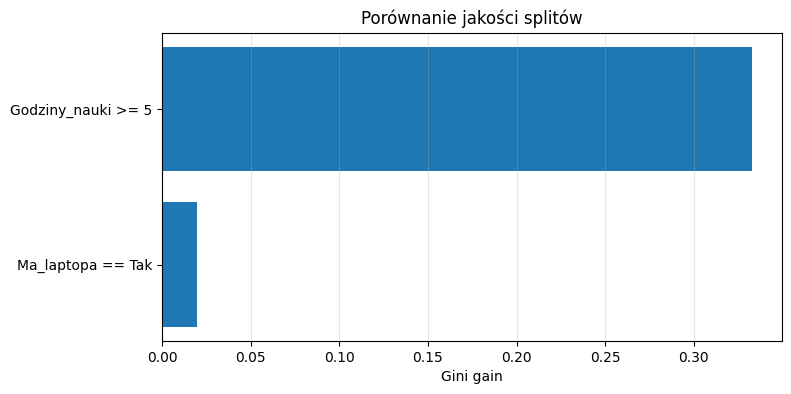

In [12]:
import matplotlib.pyplot as plt

plot_df = results[['Split', 'Gain']].sort_values('Gain', ascending=True)

plt.figure(figsize=(8,4))
plt.barh(plot_df['Split'], plot_df['Gain'])
plt.xlabel('Gini gain')
plt.title('Porównanie jakości splitów')
plt.grid(axis='x', alpha=0.3)
plt.show()

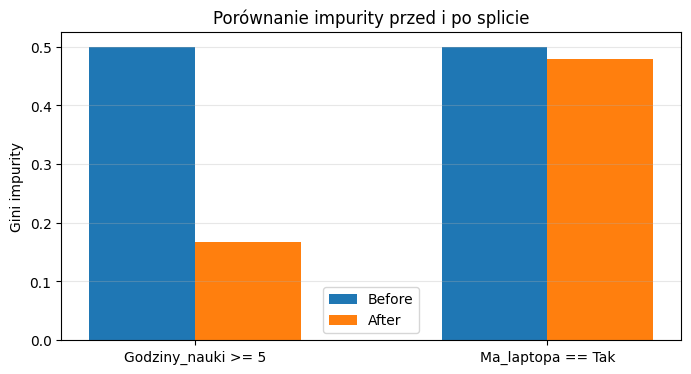

In [13]:
plot_df = results[['Split', 'G_before', 'G_after']]

x = range(len(plot_df))

plt.figure(figsize=(8,4))
plt.bar([i - 0.15 for i in x], plot_df['G_before'], width=0.3, label='Before')
plt.bar([i + 0.15 for i in x], plot_df['G_after'], width=0.3, label='After')

plt.xticks(list(x), plot_df['Split'])
plt.ylabel('Gini impurity')
plt.title('Porównanie impurity przed i po splicie')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Kodowanie Ma_laptopa: {'Nie': np.int64(0), 'Tak': np.int64(1)}


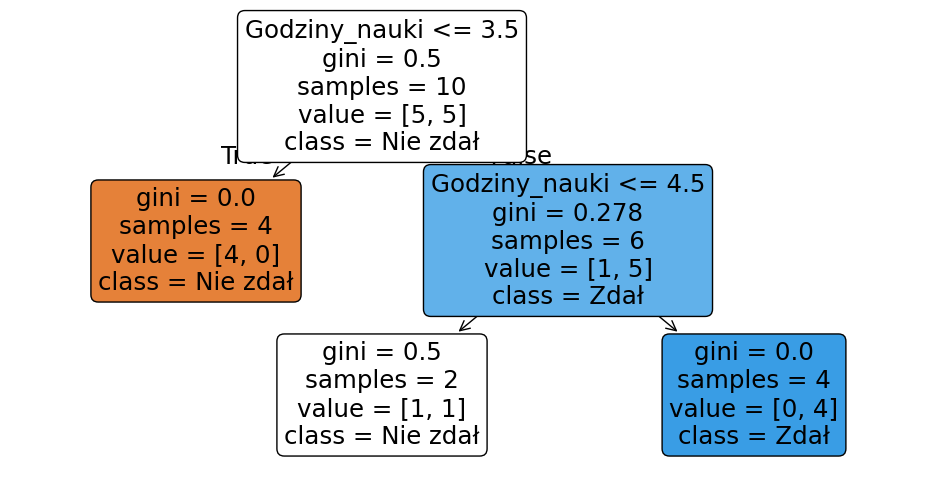

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# kodowanie zmiennej kategorycznej
df2 = df_students.copy()
le = LabelEncoder()
df2['Ma_laptopa'] = le.fit_transform(df2['Ma_laptopa'])  # np. Nie/Tak -> 0/1
print('Kodowanie Ma_laptopa:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df2[['Godziny_nauki', 'Ma_laptopa']]
y = df2['Zdal']

clf_students = DecisionTreeClassifier(max_depth=2, criterion='gini', random_state=0)
clf_students.fit(X, y)

plt.figure(figsize=(12,6))
plot_tree(
    clf_students,
    feature_names=['Godziny_nauki', 'Ma_laptopa'],
    class_names=['Nie zdał', 'Zdał'],
    filled=True,
    rounded=True
)
plt.show()

### Jak czytać progi `3.5` i `4.5`?

W danych nie musi istnieć osoba z dokładnie `3.5` godziny nauki.

Dla cechy liczbowej model sprawdza granice między kolejnymi wartościami.
Przykładowo granica:

```text
Godziny_nauki <= 3.5
```

rozdziela obserwacje tak:

```text
0, 1, 2, 3 godziny  -> lewa gałąź
4, 5, 6, 7, 8 godzin -> prawa gałąź
```

W drzewie `True`/`False` dotyczy kierunku przejścia po warunku:
`True` idzie w lewo, a `False` w prawo.

Kolor węzła oznacza natomiast przewidywaną klasę, a nie `True`/`False`.


In [15]:
from sklearn.tree import export_graphviz

try:
    import graphviz

    dot_data = export_graphviz(
        clf_students,
        out_file=None,
        feature_names=['Godziny_nauki', 'Ma_laptopa'],
        class_names=['Nie zdał', 'Zdał'],
        filled=True,
        rounded=True,
        special_characters=True
    )

    graph = graphviz.Source(dot_data)
    graph
except ModuleNotFoundError:
    print("Pakiet graphviz nie jest zainstalowany. Drzewo powyżej z plot_tree() pokazuje tę samą strukturę.")
    print("Żeby użyć Graphviz, zainstaluj pakiet Pythonowy graphviz oraz program Graphviz w systemie.")


### Co robi Graphviz?

`Graphviz` nie uczy modelu i nie wybiera splitów.

Model jest już wytrenowany wcześniej przez:

```python
clf_students.fit(X, y)
```

Funkcja `export_graphviz()` bierze gotową strukturę drzewa z modelu
i zapisuje ją jako tekstowy opis grafu w formacie DOT.

Potem:

```python
graphviz.Source(dot_data)
```

czyta ten opis i renderuje go jako rysunek.

Czyli cały proces wygląda tak:

```text
dane -> DecisionTreeClassifier -> wytrenowane drzewo -> DOT -> Graphviz -> rysunek
```

Warto zapamiętać: `plot_tree()` i `Graphviz` pokazują to samo drzewo,
tylko w innej formie graficznej.


## Schemat porównania splitów

Cały zbiór
$G = 0.5$

├── Split: `Godziny_nauki >= 5`
│   ├── Left: 4 obserwacje, same 1, $G_L = 0$
│   ├── Right: 6 obserwacji, prawie same 0, $G_R \approx 0.278$
│   └── Gain $\approx 0.333$
│
└── Split: `Ma_laptopa == Tak`
    ├── Left: 5 obserwacji, klasy mieszane, $G_L = 0.48$
    ├── Right: 5 obserwacji, klasy mieszane, $G_R = 0.48$
    └── Gain $= 0.02$